In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# Dataset de CICO
# X = Cantidad de estudiantes que ingresaron
# Y = Cantidad de estudiantes que se titularon

X = [120, 150, 135, 180, 200, 210, 190, 170, 220, 250,
     240, 260, 280, 160, 145, 300, 290, 275, 310, 320,
     330, 230, 205, 175, 195]

Y = [55, 68, 62, 85, 90, 98, 88, 75, 105, 115,
     110, 120, 135, 70, 65, 145, 140, 125, 150, 155,
     160, 100, 95, 80, 87]

print("Total de datos X:", len(X))
print("Total de datos Y:", len(Y))

Total de datos X: 25
Total de datos Y: 25


In [3]:
class CicoDataset(Dataset):

    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1, 1)
        self.Y = torch.tensor(Y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


dataset = CicoDataset(X, Y)

dataloader = DataLoader(
    dataset,
    batch_size=5,
    shuffle=True
)

print("Cantidad de datos:", len(dataset))
print("Cantidad de lotes:", len(dataloader))

Cantidad de datos: 25
Cantidad de lotes: 5


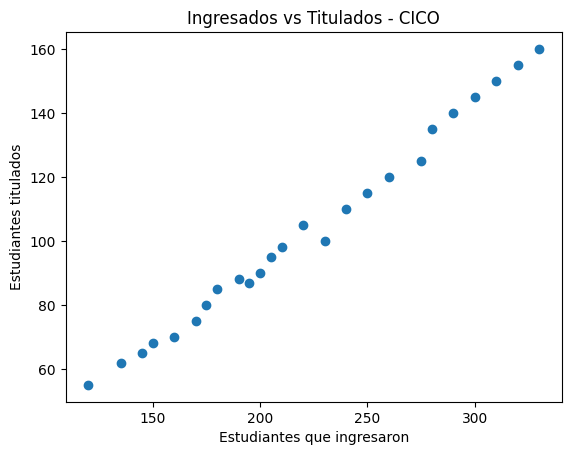

In [4]:
plt.scatter(X, Y)

plt.xlabel("Estudiantes que ingresaron")
plt.ylabel("Estudiantes titulados")
plt.title("Ingresados vs Titulados - CICO")

plt.show()

In [5]:
import torch.nn as nn

class ModeloRegresion(nn.Module):

    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


modelo = ModeloRegresion()

print(modelo)

ModeloRegresion(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [6]:
print("w inicial:", modelo.linear.weight.item())
print("b inicial:", modelo.linear.bias.item())

w inicial: -0.07199978828430176
b inicial: 0.6705285310745239


In [7]:
# Función de costo
criterio = nn.MSELoss()

# Optimizador
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)

print("Función de costo:", criterio)
print("Optimizador:", optimizador)

Función de costo: MSELoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [8]:
epochs = 3000

for epoch in range(epochs):
    perdida_total = 0

    for x_batch, y_batch in dataloader:

        # Predicción
        y_pred = modelo(x_batch)

        # Calcular error
        loss = criterio(y_pred, y_batch)

        # Limpiar gradientes anteriores
        optimizador.zero_grad()

        # Calcular gradientes
        loss.backward()

        # Actualizar w y b
        optimizador.step()

        perdida_total += loss.item()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}: Loss = {perdida_total / len(dataloader):.4f}")

Epoch 500: Loss = 12.7000
Epoch 1000: Loss = 9.6776
Epoch 1500: Loss = 7.8329
Epoch 2000: Loss = 7.5032
Epoch 2500: Loss = 8.5035
Epoch 3000: Loss = 8.3930


In [9]:
w = modelo.linear.weight.item()
b = modelo.linear.bias.item()

print("Valor final de w:", round(w, 4))
print("Valor final de b:", round(b, 4))

Valor final de w: 0.5086
Valor final de b: -8.9934


In [10]:
modelo.eval()

X_tensor = torch.tensor(X, dtype=torch.float32).reshape(-1, 1)
Y_tensor = torch.tensor(Y, dtype=torch.float32).reshape(-1, 1)

with torch.no_grad():
    predicciones = modelo(X_tensor)

# Error absoluto medio
mae = torch.mean(torch.abs(Y_tensor - predicciones))

# Error cuadrático medio
mse = torch.mean((Y_tensor - predicciones) ** 2)

print("MAE:", round(mae.item(), 4))
print("MSE:", round(mse.item(), 4))

MAE: 2.1567
MSE: 7.7748


In [11]:
nuevos_X = [340, 350, 360, 370, 380,
            390, 400, 410, 420, 430]

modelo.eval()

with torch.no_grad():

    for x_nuevo in nuevos_X:

        entrada = torch.tensor([[x_nuevo]], dtype=torch.float32)

        prediccion = modelo(entrada)

        print(
            f"Ingresados: {x_nuevo} -> "
            f"Titulados estimados: {prediccion.item():.2f}"
        )

Ingresados: 340 -> Titulados estimados: 163.94
Ingresados: 350 -> Titulados estimados: 169.02
Ingresados: 360 -> Titulados estimados: 174.11
Ingresados: 370 -> Titulados estimados: 179.19
Ingresados: 380 -> Titulados estimados: 184.28
Ingresados: 390 -> Titulados estimados: 189.37
Ingresados: 400 -> Titulados estimados: 194.45
Ingresados: 410 -> Titulados estimados: 199.54
Ingresados: 420 -> Titulados estimados: 204.62
Ingresados: 430 -> Titulados estimados: 209.71


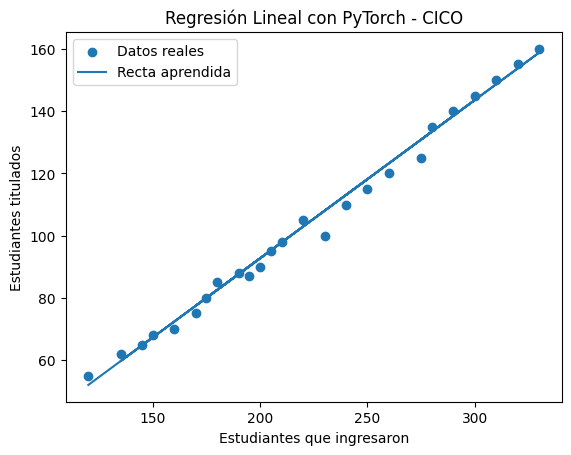

In [12]:
modelo.eval()

with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32).reshape(-1, 1)
    predicciones = modelo(X_tensor)

plt.scatter(X, Y, label="Datos reales")
plt.plot(X, predicciones.numpy(), label="Recta aprendida")

plt.xlabel("Estudiantes que ingresaron")
plt.ylabel("Estudiantes titulados")
plt.title("Regresión Lineal con PyTorch - CICO")
plt.legend()

plt.show()